## Initial Setup

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import time
import warnings
warnings.filterwarnings('ignore')

class Config:
    ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
    STEMS_PATH = os.path.join(ROOT, 'genres_stems')
    ESC50_PATH = os.path.join(ROOT, 'ESC-50-master', 'audio')
    MASHUPS_PATH = os.path.join(ROOT, 'mashups')
    TEST_CSV = os.path.join(ROOT, 'test.csv')
    
    GENRES = ["blues", "classical", "country", "disco", "hiphop", 
              "jazz", "metal", "pop", "reggae", "rock"]
    NUM_CLASSES = len(GENRES)
    
    SAMPLE_RATE = 22050
    DURATION = 10
    N_MELS = 128
    N_FFT = 2048
    HOP_LENGTH = 512
    
    BATCH_SIZE = 32
    EPOCHS = 25
    LEARNING_RATE = 0.001
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    RANDOM_STATE = 42
    
    TRAIN_SONGS_PER_GENRE = 85
    VAL_SONGS_PER_GENRE = 15
    MASHUPS_PER_GENRE = 100
    
    WANDB_PROJECT = "21f3000342-dl-genai-t12026"


config = Config()
torch.manual_seed(config.RANDOM_STATE)
np.random.seed(config.RANDOM_STATE)

## Audio processing

In [2]:

class AudioProcessor:
    def __init__(self, sample_rate=22050, n_mels=128, n_fft=2048, hop_length=512, duration=10):
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.duration = duration
        self.target_length = sample_rate * duration
        
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        self.db_transform = T.AmplitudeToDB()
    
    def load_audio(self, path):
        try:
            waveform, sr = torchaudio.load(path)
            
            if sr != self.sample_rate:
                resampler = T.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)
            
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            
            if waveform.shape[1] < self.target_length:
                padding = self.target_length - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, padding))
            else:
                waveform = waveform[:, :self.target_length]
            
            return waveform
        except:
            return None
    
    def to_mel_spectrogram(self, waveform):
        mel_spec = self.mel_transform(waveform)
        mel_spec_db = self.db_transform(mel_spec)
        return mel_spec_db
    
    def process(self, path):
        waveform = self.load_audio(path)
        if waveform is None:
            return None
        mel_spec = self.to_mel_spectrogram(waveform)
        return mel_spec


## Mashup Creation

In [3]:

class NoiseAugmentor:
    def __init__(self, esc50_path, sample_rate=22050):
        self.sample_rate = sample_rate
        self.noise_files = []
        
        if os.path.exists(esc50_path):
            from glob import glob
            self.noise_files = glob(os.path.join(esc50_path, '*.wav'))
    
    def add_noise(self, waveform, noise_level=0.01):
        if len(self.noise_files) == 0:
            return waveform
        
        try:
            noise_file = np.random.choice(self.noise_files)
            noise, sr = torchaudio.load(noise_file)
            
            if sr != self.sample_rate:
                resampler = T.Resample(sr, self.sample_rate)
                noise = resampler(noise)
            
            if noise.shape[0] > 1:
                noise = torch.mean(noise, dim=0, keepdim=True)
            
            target_len = waveform.shape[1]
            if noise.shape[1] < target_len:
                repeats = int(np.ceil(target_len / noise.shape[1]))
                noise = noise.repeat(1, repeats)[:, :target_len]
            else:
                noise = noise[:, :target_len]
            
            noise_level = np.random.uniform(0.005, noise_level)
            augmented = waveform + noise_level * noise
            
            return augmented
        except:
            return waveform



class MashupCreator:
    def __init__(self, stems_path, sample_rate=22050, duration=10):
        self.stems_path = stems_path
        self.sample_rate = sample_rate
        self.duration = duration
        self.target_length = sample_rate * duration
        self.stems = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
    
    def create_mashup(self, genre, songs_list):
        if len(songs_list) < 4:
            return None
        
        try:
            selected_songs = np.random.choice(songs_list, size=4, replace=False)
            mixed = None
            
            for i, stem in enumerate(self.stems):
                stem_path = os.path.join(self.stems_path, genre, selected_songs[i], stem)
                
                if not os.path.exists(stem_path):
                    continue
                
                try:
                    waveform, sr = torchaudio.load(stem_path)
                    
                    if sr != self.sample_rate:
                        resampler = T.Resample(sr, self.sample_rate)
                        waveform = resampler(waveform)
                    
                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)
                    
                    if waveform.shape[1] < self.target_length:
                        padding = self.target_length - waveform.shape[1]
                        waveform = torch.nn.functional.pad(waveform, (0, padding))
                    else:
                        waveform = waveform[:, :self.target_length]
                    
                    volume = np.random.uniform(0.3, 1.0)
                    waveform = waveform * volume
                    
                    if mixed is None:
                        mixed = waveform
                    else:
                        mixed = mixed + waveform
                except:
                    continue
            
            if mixed is None:
                return None
            
            max_val = torch.max(torch.abs(mixed))
            if max_val > 0:
                mixed = mixed / max_val * 0.9
            
            return mixed
            
        except:
            return None
    
    def full_song_mix(self, genre, song):
        song_path = os.path.join(self.stems_path, genre, song)
        
        if not os.path.isdir(song_path):
            return None
        
        try:
            mixed = None
            
            for stem in self.stems:
                stem_path = os.path.join(song_path, stem)
                
                if not os.path.exists(stem_path):
                    continue
                
                try:
                    waveform, sr = torchaudio.load(stem_path)
                    
                    if sr != self.sample_rate:
                        resampler = T.Resample(sr, self.sample_rate)
                        waveform = resampler(waveform)
                    
                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)
                    
                    if waveform.shape[1] < self.target_length:
                        padding = self.target_length - waveform.shape[1]
                        waveform = torch.nn.functional.pad(waveform, (0, padding))
                    else:
                        waveform = waveform[:, :self.target_length]
                    
                    volume = np.random.uniform(0.4, 1.0)
                    waveform = waveform * volume
                    
                    if mixed is None:
                        mixed = waveform
                    else:
                        mixed = mixed + waveform
                except:
                    continue

            if mixed is None:
                return None
            
            max_val = torch.max(torch.abs(mixed))
            if max_val > 0:
                mixed = mixed / max_val * 0.9
            
            return mixed
            
        except:
            return None


## Datasets

In [4]:

class AudioDataset(Dataset):
    def __init__(self, spectrograms, labels):
        self.spectrograms = spectrograms
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        spectrogram = self.spectrograms[idx]
        label = self.labels[idx]
        return spectrogram, label


def split_songs_by_genre():
    train_songs = {}
    val_songs = {}
    
    for genre in config.GENRES:
        genre_path = os.path.join(config.STEMS_PATH, genre)
        
        if not os.path.isdir(genre_path):
            continue
        
        songs = [s for s in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, s))]
        
        np.random.shuffle(songs)
        
        train_songs[genre] = songs[:config.TRAIN_SONGS_PER_GENRE]
        val_songs[genre] = songs[config.TRAIN_SONGS_PER_GENRE:config.TRAIN_SONGS_PER_GENRE + config.VAL_SONGS_PER_GENRE]
    
    return train_songs, val_songs


def prepare_data(songs_dict, mashup_creator, noise_augmentor, processor, label_to_idx, is_training=True):
    all_spectrograms = []
    all_labels = []
    
    for genre in tqdm(config.GENRES, desc="Processing songs"):
        if genre not in songs_dict:
            continue
        
        songs = songs_dict[genre]
        
        for song in songs:
            mixed = mashup_creator.full_song_mix(genre, song)
            
            if mixed is not None:
                if is_training:
                    mixed = noise_augmentor.add_noise(mixed, noise_level=0.02)
                
                mel_spec = processor.to_mel_spectrogram(mixed)
                all_spectrograms.append(mel_spec.squeeze(0))
                all_labels.append(label_to_idx[genre])
                
                if is_training:
                    mixed_aug = noise_augmentor.add_noise(mixed, noise_level=0.03)
                    mel_spec_aug = processor.to_mel_spectrogram(mixed_aug)
                    all_spectrograms.append(mel_spec_aug.squeeze(0))
                    all_labels.append(label_to_idx[genre])
        
        gc.collect()
    
    if is_training:
        for genre in tqdm(config.GENRES, desc="Creating mashups"):
            if genre not in songs_dict:
                continue
            
            songs = songs_dict[genre]
            
            for _ in range(config.MASHUPS_PER_GENRE):
                waveform = mashup_creator.create_mashup(genre, songs)
                
                if waveform is not None:
                    waveform = noise_augmentor.add_noise(waveform, noise_level=0.02)
                    mel_spec = processor.to_mel_spectrogram(waveform)
                    
                    all_spectrograms.append(mel_spec.squeeze(0))
                    all_labels.append(label_to_idx[genre])
            
            gc.collect()
    
    spectrograms = torch.stack(all_spectrograms)
    labels = torch.tensor(all_labels, dtype=torch.long)
    
    return spectrograms, labels


def prepare_test_data(processor, label_to_idx):
    test_df = pd.read_csv(config.TEST_CSV)
    
    all_spectrograms = []
    test_ids = []
    
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Processing test"):
        test_id = row['id']
        audio_file = f"song{str(test_id).zfill(4)}.wav"
        audio_path = os.path.join(config.MASHUPS_PATH, audio_file)
        
        if not os.path.exists(audio_path):
            continue
        
        try:
            mel_spec = processor.process(audio_path)
            
            if mel_spec is not None:
                all_spectrograms.append(mel_spec.squeeze(0))
                test_ids.append(test_id)
        except:
            continue
        
        if idx % 500 == 0:
            gc.collect()
    
    spectrograms = torch.stack(all_spectrograms)
    
    return spectrograms, test_ids


## CNN Model Architecture

In [5]:

class AudioCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.fc(x)
        return x


## Training Functions

In [6]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for spectrograms, labels in dataloader:
        spectrograms = spectrograms.unsqueeze(1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(spectrograms)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for spectrograms, labels in dataloader:
            spectrograms = spectrograms.unsqueeze(1).to(device)
            labels = labels.to(device)
            
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, macro_f1


def predict(model, dataloader, device):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for spectrograms in dataloader:
            if isinstance(spectrograms, tuple):
                spectrograms = spectrograms[0]
            
            spectrograms = spectrograms.unsqueeze(1).to(device)
            outputs = model(spectrograms)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
    
    return all_preds


## Data Preparation

In [7]:

total_start = time.time()

label_to_idx = {genre: idx for idx, genre in enumerate(config.GENRES)}
idx_to_label = {v: k for k, v in label_to_idx.items()}

processor = AudioProcessor(
    sample_rate=config.SAMPLE_RATE,
    n_mels=config.N_MELS,
    n_fft=config.N_FFT,
    hop_length=config.HOP_LENGTH,
    duration=config.DURATION
)

noise_augmentor = NoiseAugmentor(config.ESC50_PATH, config.SAMPLE_RATE)
mashup_creator = MashupCreator(config.STEMS_PATH, config.SAMPLE_RATE, config.DURATION)

train_songs, val_songs = split_songs_by_genre()

# Preparing training data
X_train, y_train = prepare_data(
    train_songs, mashup_creator, noise_augmentor, processor, label_to_idx, is_training=True
)

print(f"Training samples: {len(y_train)}")
print(f"Training spectrogram shape: {X_train.shape}")

# Preparing validation data
X_val, y_val = prepare_data(
    val_songs, mashup_creator, noise_augmentor, processor, label_to_idx, is_training=False
)
print(f"Validation samples: {len(y_val)}")

train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

model = AudioCNN(num_classes=config.NUM_CLASSES).to(config.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}") 

Creating mashups: 100%|██████████| 10/10 [07:10<00:00, 43.06s/it]


Training samples: 2700
Training spectrogram shape: torch.Size([2700, 128, 431])


Processing songs: 100%|██████████| 10/10 [01:36<00:00,  9.67s/it]


Validation samples: 150

Total parameters: 422,986
Trainable parameters: 422,986


## WandB Setup

In [8]:
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

wandb.login()

wandb: Currently logged in as: 21f3000342 (21f3000342-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [9]:
wandb.init(
    project=config.WANDB_PROJECT,
    name=f"cnn_{time.strftime('%Y%m%d_%H%M%S')}",
    config={
        "architecture": "AudioCNN",
        "sample_rate": config.SAMPLE_RATE,
        "duration": config.DURATION,
        "n_mels": config.N_MELS,
        "n_fft": config.N_FFT,
        "hop_length": config.HOP_LENGTH,
        "batch_size": config.BATCH_SIZE,
        "epochs": config.EPOCHS,
        "learning_rate": config.LEARNING_RATE,
        "num_classes": config.NUM_CLASSES,
        "train_songs_per_genre": config.TRAIN_SONGS_PER_GENRE,
        "val_songs_per_genre": config.VAL_SONGS_PER_GENRE,
        "mashups_per_genre": config.MASHUPS_PER_GENRE,
        "total_params": total_params,
        "trainable_params": trainable_params
    }
)

wandb: setting up run d2zqw46f
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_155236-d2zqw46f
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn_20260304_155236
wandb: ⭐️ View project at https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026
wandb: 🚀 View run at https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026/runs/d2zqw46f


## Model Training

In [10]:

best_f1 = 0.0
best_model_state = None
metrics = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

print("\nTraining...")
for epoch in range(config.EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, config.DEVICE)
    
    scheduler.step(val_f1)

    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "learning_rate": optimizer.param_groups[0]['lr']
    })
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch+1}/{config.EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

model.load_state_dict(best_model_state)

val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, config.DEVICE)
print(f"\nBest Validation - Acc: {val_acc:.4f}, F1: {val_f1:.4f}")


Training...
Epoch 1/25 - Train Loss: 1.7315, Train Acc: 0.3478, Val Loss: 1.5869, Val Acc: 0.4000, Val F1: 0.3380
Epoch 2/25 - Train Loss: 1.4278, Train Acc: 0.4848, Val Loss: 1.1920, Val Acc: 0.5933, Val F1: 0.5685
Epoch 3/25 - Train Loss: 1.1773, Train Acc: 0.5822, Val Loss: 1.4534, Val Acc: 0.5733, Val F1: 0.5136
Epoch 4/25 - Train Loss: 1.0826, Train Acc: 0.6256, Val Loss: 1.0774, Val Acc: 0.6133, Val F1: 0.6047
Epoch 5/25 - Train Loss: 0.9843, Train Acc: 0.6652, Val Loss: 1.2021, Val Acc: 0.5933, Val F1: 0.5651
Epoch 6/25 - Train Loss: 0.8944, Train Acc: 0.6907, Val Loss: 1.4243, Val Acc: 0.5467, Val F1: 0.4901
Epoch 7/25 - Train Loss: 0.8171, Train Acc: 0.7219, Val Loss: 1.2965, Val Acc: 0.6200, Val F1: 0.6181
Epoch 8/25 - Train Loss: 0.7502, Train Acc: 0.7444, Val Loss: 0.8668, Val Acc: 0.6867, Val F1: 0.6658
Epoch 9/25 - Train Loss: 0.7341, Train Acc: 0.7581, Val Loss: 1.0857, Val Acc: 0.6667, Val F1: 0.6394
Epoch 10/25 - Train Loss: 0.6236, Train Acc: 0.7911, Val Loss: 1.4370

## Visualization and Analysis


 ----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

       blues     0.7500    0.4000    0.5217        15
   classical     1.0000    0.9333    0.9655        15
     country     0.9000    0.6000    0.7200        15
       disco     1.0000    0.7333    0.8462        15
      hiphop     1.0000    0.6667    0.8000        15
        jazz     0.4286    1.0000    0.6000        15
       metal     0.8333    0.6667    0.7407        15
         pop     0.6429    0.6000    0.6207        15
      reggae     0.9231    0.8000    0.8571        15
        rock     0.4783    0.7333    0.5789        15

    accuracy                         0.7133       150
   macro avg     0.7956    0.7133    0.7251       150
weighted avg     0.7956    0.7133    0.7251       150




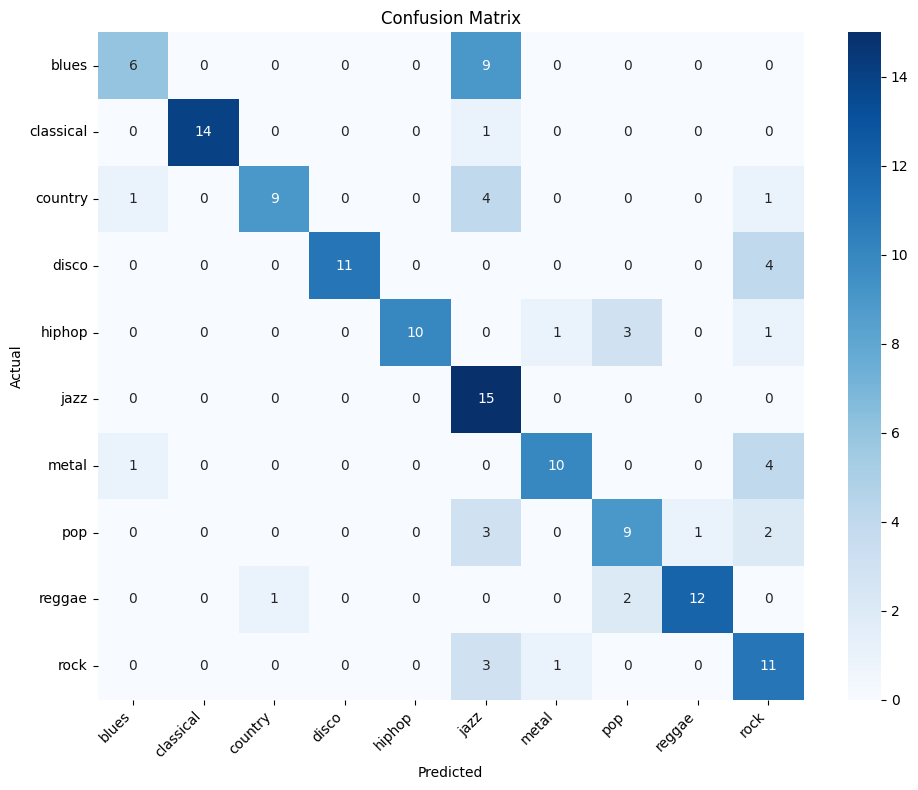

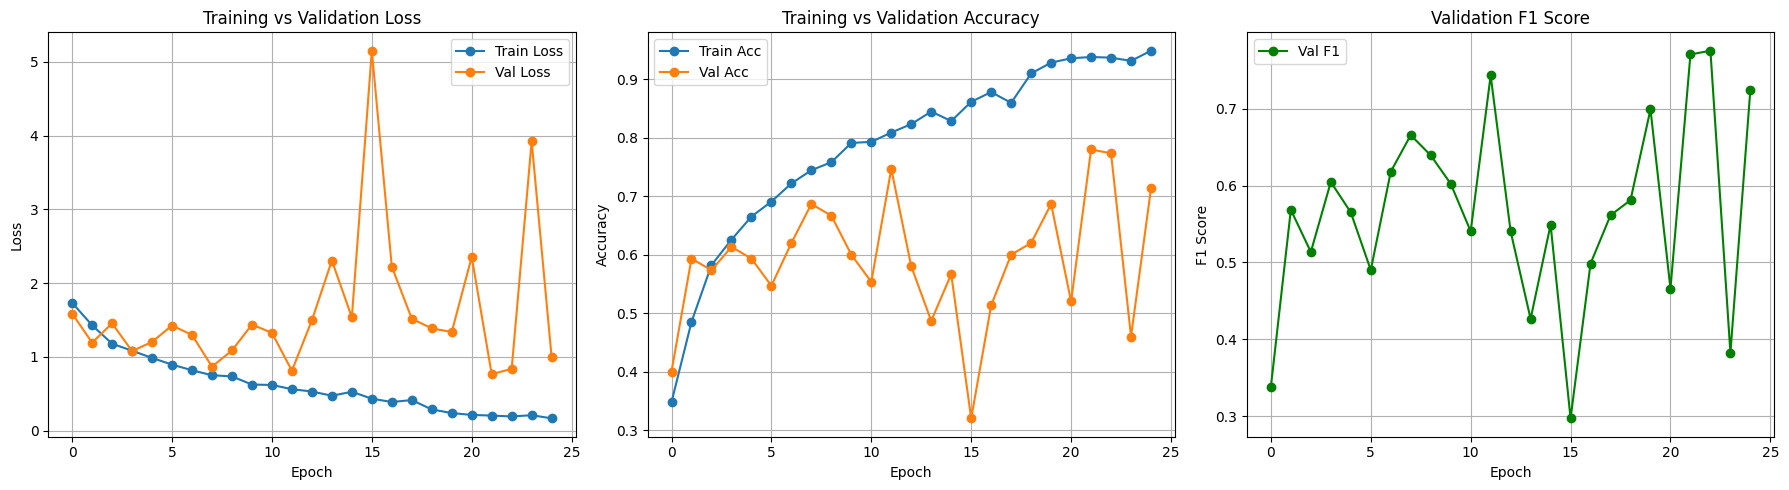

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb: learning_rate █████████████████▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇███████
wandb:    train_loss █▇▆▅▅▄▄▄▄▃▃▃▃▂▃▂▂▂▂▁▁▁▁▁▁
wandb:       val_acc ▂▅▅▅▅▄▆▇▆▅▅▇▅▄▅▁▄▅▆▇▄██▃▇
wandb:        val_f1 ▂▅▄▆▅▄▆▆▆▅▅█▅▃▅▁▄▅▅▇▃██▂▇
wandb:      val_loss ▂▂▂▁▂▂▂▁▂▂▂▁▂▃▂█▃▂▂▂▄▁▁▆▁
wandb: 
wandb: Run summary:
wandb:         epoch 25
wandb: learning_rate 0.0005
wandb:     train_acc 0.94889
wandb:    train_loss 0.16559
wandb:       val_acc 0.71333
wandb:        val_f1 0.72509
wandb:      val_loss 0.99138
wandb: 
wandb: 🚀 View run cnn_20260304_155236 at: https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026/runs/d2zqw46f
wandb: ⭐️ View project at: https://wandb.ai/21f3000342-indian-institute-of-technology-madras/21f3000342-dl-genai-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wand

In [11]:
model.eval()
all_preds = []
all_labels_list = []

with torch.no_grad():
    for spectrograms_batch, labels_batch in val_loader:
        spectrograms_batch = spectrograms_batch.unsqueeze(1).to(config.DEVICE)
        outputs = model(spectrograms_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels_batch.numpy())


print("\n ----- CLASSIFICATION REPORT -----")
cr = classification_report(
    all_labels_list, 
    all_preds, 
    target_names=config.GENRES,
    digits=4
)
print(cr)
print()

cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=config.GENRES,
    yticklabels=config.GENRES
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Loss plot
axes[0].plot(metrics['train_loss'], label='Train Loss', marker='o')
axes[0].plot(metrics['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(metrics['train_acc'], label='Train Acc', marker='o')
axes[1].plot(metrics['val_acc'], label='Val Acc', marker='o')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# F1 Score plot
axes[2].plot(metrics['val_f1'], label='Val F1', marker='o', color='green')
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

wandb.finish()

## Test Data and Inference

In [12]:

class TestDataset(Dataset):
    def __init__(self, spectrograms):
        self.spectrograms = spectrograms
    
    def __len__(self):
        return len(self.spectrograms)
    
    def __getitem__(self, idx):
        return self.spectrograms[idx]


test_spectrograms, test_ids = prepare_test_data(processor, label_to_idx)

test_dataset = TestDataset(test_spectrograms)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

predictions = predict(model, test_loader, config.DEVICE)
pred_labels = [idx_to_label[pred] for pred in predictions]

submission = pd.DataFrame({'id': test_ids, 'genre': pred_labels})
submission.to_csv('submission.csv', index=False)

total_time = time.time() - total_start

print(f"\nTotal time: {total_time/3600:.1f} hrs")
print(f"Best Validation F1: {best_f1:.4f}")
print(f"\nPrediction distribution:")
print(submission['genre'].value_counts().sort_index())


Processing test: 100%|██████████| 3020/3020 [02:00<00:00, 25.15it/s]



Total time: 0.4 hrs
Best Validation F1: 0.7756

Prediction distribution:
genre
blues         69
classical     70
country       72
disco         81
hiphop       285
jazz         939
metal        158
pop          656
reggae       166
rock         524
Name: count, dtype: int64
